In [ ]:
# --- notebook paths ---
import sys
from pathlib import Path

# Ensure repo root + src/ are importable (robust to working directory)
REPO_ROOT = Path.cwd().resolve()
while not ((REPO_ROOT / "src").exists() and (REPO_ROOT / "data").exists() and (REPO_ROOT / "notebooks").exists()):
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not locate repo root (expected src/, data/, notebooks/).")
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

# Shared path constants (data/, results/, etc.)
from notebooks.set_up import (
    ensure_dirs,
    REPO_ROOT as _REPO_ROOT,  # optional: sanity check
    DATA_DIR, DEMO_DIR, PRIVATE_DIR, SYNTH_DIR,
    RESULTS_DIR, OUTPUT_DIR, VALIDATION_DIR, CATE_DIR, STUDY_DESIGN_DIR,
    TABLE_DIR, FIG_DIR,
)

ensure_dirs()

# Optional sanity check (can remove after you trust it)
assert _REPO_ROOT == REPO_ROOT
# input data path
output_path = str(PRIVATE_DIR) + "/"
# output result path
output_result = str(VALIDATION_DIR) + "/"
DATA_MODE = "private"

In [0]:
from pyspark.sql import functions as sparkF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# --- CausalMix package ---
from causalmix import (
    CausalMix,
    conVAE,
    SynthEval,
    CausalEval,
    DataSchema,
    VarIndex,
    fit_metadata,
    preprocess_with_meta,
    build_table_distributional_fidelity,
    build_table_privacy,
    build_table_causal_structure,
    eval_tables_mean,
    single_column_plot,
    pair_column_plot,
    plot_joint_embedding_2d,
)

In [0]:
# check GPU availability
import torch
import os

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU") # Used the node g6e.2xlarge [L40S]
print("numer of cores:",os.cpu_count())

CUDA available: True
GPU name: NVIDIA L40S
numer of cores: 8


#Import mcrpc dataset


In [ ]:
# import mcrpc dataset with only the exposure, outcome and covariates in the analysis
# Real dataset (private) must be stored locally (not committed):
#   data/private/mcrpc_real.parquet
# For a public demo run, place a small sample under:
#   data/demo/mcrpc_real_demo.parquet

if DATA_MODE == "private":
    real_path = PRIVATE_DIR / "mcrpc_real.parquet"
elif DATA_MODE == "demo":
    real_path = DEMO_DIR / "mcrpc_real_demo.parquet"
else:
    raise ValueError("DATA_MODE must be 'private' or 'demo'.")

if not real_path.exists():
    raise FileNotFoundError(
        f"Expected dataset not found at {real_path}.\n"
        "If using demo mode, ensure the demo file is placed under data/demo/.\n"
        "If using private mode, place the confidential dataset under data/private/."
    )

mcrpc_data = pd.read_parquet(real_path)
print(mcrpc_data) # 18 covariates, 1 outcome, 1 treatment

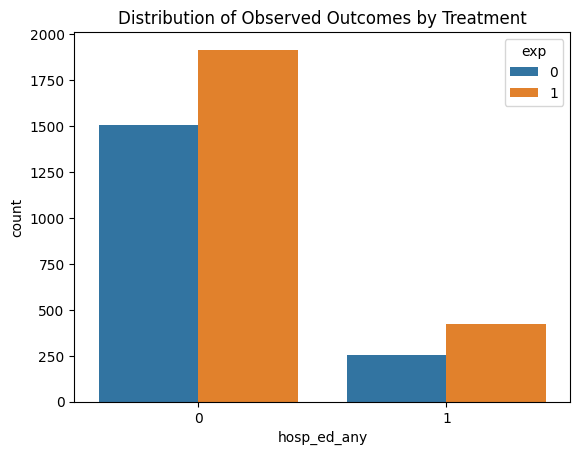

In [0]:
sns.countplot(x='hosp_ed_any', hue='exp', data=mcrpc_data)
plt.title("Distribution of Observed Outcomes by Treatment")
plt.show()

In [0]:
# identify variable types and dimensions, which will be used as input for CausalMix
mcrpc_data.info()
# numerical_var = mcrpc_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_var = ["age", "Charlson"]
print(numerical_var)
categorical_var = mcrpc_data.select_dtypes(include=['object', 'category']).columns.to_list()
print(categorical_var)
binary_var = mcrpc_data.columns.difference(categorical_var + numerical_var).to_list()
print(binary_var)
unique_levels = {col: mcrpc_data[col].nunique() for col in categorical_var}
print(unique_levels)
X = mcrpc_data.drop(["exp", "hosp_ed_any"], axis=1)
print(X.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4098 entries, 0 to 4097
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   exp                4098 non-null   int32  
 1   hosp_ed_any        4098 non-null   int32  
 2   race_cat           4098 non-null   int32  
 3   age                4098 non-null   float64
 4   mets_site          4098 non-null   object 
 5   Enzalutamide_prev  4098 non-null   int32  
 6   Abiraterone_prev   4098 non-null   int32  
 7   trt_prev           4098 non-null   object 
 8   dementia_pre       4098 non-null   int32  
 9   any_infect_pre     4098 non-null   int32  
 10  arf_renal_pre      4098 non-null   int32  
 11  htn_pre            4098 non-null   int32  
 12  dm_pre             4098 non-null   int32  
 13  smoker_copd_pre    4098 non-null   int32  
 14  cvd_pre            4098 non-null   int32  
 15  Charlson           4098 non-null   int32  
 16  anti_diab_pre      4098 